Image Classification on Intel Image Classification Dataset.
The dataset contains 14k images in Train and 3k in Test with 6 categories.

My attempt uses Progressive Unfreezing on the ResNet-50 model.

This code is tailored to run best on RTX 4000 series graphic card utilizing CUDA Deep Neural Network libraries and Automatic Mixed Precision(AMP) for better performance.

In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import wandb
torch.backends.cudnn.benchmark = True

In [12]:
import torchvision.models as models
from torchvision.models import ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
transform = weights.transforms()

Data Augmentation (Training):
- **Normalization** : We use the ImageNet mean and std the resNet model is orginally trained on to convert the Intel Image dataset on the same channel for similar performance by resNet
- **Random Resized Crop**: Randomly select a crop covering ~80% of the image and resizing it to 224x224
- **Random Horizontal Flip**: Flip half of the image horizontally
- **Color Jitter**: Alters the image's Brightness, Contrast, Saturation and Hue
- **Random Perspective**: Simulates a shift in viewing angle of an image
- **Random Erasing**: Randomly removes a rectangular region.

Data Augmentation (Test):
- **Resize**: Resizes the shorter side to 256 pixels.
- **CenterCrop**: Extracts the center 224 × 224 region.
- **Normalization**

Notes:
- These transformations were made taking into account the orignal dataset the model was trained on and the current dataset. 
- Since these are nature images and landscapes relevant transformation were applied that reflect situation that occur naturally while capturing such images
- Test Augmentation is limited for consistent results

In [13]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomPerspective(
    distortion_scale=0.2,
    p=0.3
),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02,0.15),
        ratio=(0.3,3.3)
    )
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.ImageFolder(
    root="archive/seg_train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root="archive/seg_test",
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

Sample from the training dataset

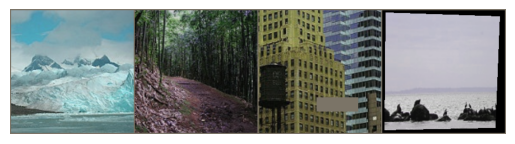

glacier forest buildings sea  


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# functions to show an image


def imshow(img):
    img = img * std + mean
    img = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:4]))
# print labels
print(' '.join(f'{train_dataset.classes[labels[j]]:5s}' for j in range(4)))

In [15]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="shehryar11w-private",
    # Set the wandb project where this run will be logged.
    project="intel-images",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 1e-3,
        "architecture": "ResNet - Progressive Unfreezing",
        "dataset": "Intel-Image",
        "epochs": 15,
    },
)


We use the resNet model (conv_base only) and add a fc layer according to dataset categories

In [16]:
import torch.nn as nn
import torch.nn.functional as F

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 6)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
device

device(type='cuda')

- We use Cross Entropy Loss with label smoothing (allows network to not be 100% confident on a prediction and have mixed confidence - better for generalization)
- We use AdamW for optimization along with weight decay
- Cosine Annealing is used as a Learning Rate Scheduler
- AMP scaling is used for better performance (Only if using Ada Lovelace Architecture)

In [18]:
import torch.optim as optim


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.fc.parameters(),lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15,
    eta_min=1e-6
)
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

This covers the entire test-train loop over 15 epochs:
- **Progressive Unfreezing**: Unlock last layer after 5 epochs and entire network after 10 epochs

In [19]:
best_acc = 0
for epoch in range(15):  # loop over the dataset multiple times

    #Progressive Unfreezing
    if epoch == 5: # Epoch 6: unfreeze layer4
        print("Unfreezing layer4")

        for param in model.layer4.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-4,
            weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=5,
            eta_min=1e-6
        )

    if epoch == 10:  # Epoch 11: unfreeze everything
        print("Unfreezing entire network")

        for param in model.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=1e-5,
            weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=5,
            eta_min=1e-7
        )


    ### Train
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        # zero the parameter gradients
        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        # forward + backward + optimize using scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)

        scaler.update()
        # log statistics
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f'[{epoch + 1}] Train loss: {epoch_loss:.4f}')

    ### Validate
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda") ):
            for inputs, labels in test_loader:

                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

    val_loss /= len(test_loader)
    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}: Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "lr": scheduler.get_last_lr()[0]
    })

    scheduler.step()
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pth")

print('Finished Training')

[1] Train loss: 0.8190
Epoch 1: Val Loss = 0.6753, Val Acc = 89.90%
[2] Train loss: 0.6758
Epoch 2: Val Loss = 0.6544, Val Acc = 90.73%
[3] Train loss: 0.6607
Epoch 3: Val Loss = 0.6463, Val Acc = 91.33%
[4] Train loss: 0.6437
Epoch 4: Val Loss = 0.6375, Val Acc = 91.60%
[5] Train loss: 0.6382
Epoch 5: Val Loss = 0.6378, Val Acc = 91.63%
Unfreezing layer4
[6] Train loss: 0.6098
Epoch 6: Val Loss = 0.5871, Val Acc = 93.03%
[7] Train loss: 0.5578
Epoch 7: Val Loss = 0.5725, Val Acc = 93.77%
[8] Train loss: 0.5277
Epoch 8: Val Loss = 0.5701, Val Acc = 93.83%
[9] Train loss: 0.5086
Epoch 9: Val Loss = 0.5671, Val Acc = 93.97%
[10] Train loss: 0.4973
Epoch 10: Val Loss = 0.5697, Val Acc = 93.90%
Unfreezing entire network
[11] Train loss: 0.4938
Epoch 11: Val Loss = 0.5659, Val Acc = 94.23%
[12] Train loss: 0.4903
Epoch 12: Val Loss = 0.5639, Val Acc = 94.17%
[13] Train loss: 0.4855
Epoch 13: Val Loss = 0.5641, Val Acc = 94.23%
[14] Train loss: 0.4806
Epoch 14: Val Loss = 0.5667, Val Acc = 9

In [20]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,███▇▇▂▂▁▁▁▁▁▁▁▁
train_loss,█▅▅▄▄▄▃▂▂▁▁▁▁▁▁
val_accuracy,▁▂▃▄▄▆▇▇█▇█████
val_loss,█▇▆▆▆▂▂▁▁▁▁▁▁▁▁
epoch,15
lr,0.0
train_loss,0.48153
val_accuracy,94.2
val_loss,0.56527
